# EDA — Bases de datos sintéticas
**Proyecto**: Recomendador de Eventos · Gastronomía · Lugares de interés — Euskadi  
**Población objetivo**: 45-65 años · Distribución territorial: Bizkaia 50%, Gipuzkoa 35%, Araba 15%

---

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# Estilo global
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Paleta coherente con los tres dominios
COL_EVT  = "#4C72B0"   # azul  → eventos
COL_GAST = "#DD8452"   # naranja → gastronomía
COL_LUG  = "#55A868"   # verde → lugares

# ── Carga de datos
eventos  = pd.read_csv("data_sintetica\datos_eventos.csv")
gastro   = pd.read_csv("data_sintetica\datos_gastronomia.csv")
lugares  = pd.read_csv("data_sintetica\datos_lugares_interes.csv")

print("Shapes → Eventos:", eventos.shape,
      "| Gastronomía:", gastro.shape,
      "| Lugares:", lugares.shape)


Shapes → Eventos: (2000, 15) | Gastronomía: (2000, 16) | Lugares: (2000, 11)


---
## 1 · Visión general de cada dataset

In [10]:
for nombre, df in [("Eventos", eventos), ("Gastronomía", gastro), ("Lugares de interés", lugares)]:
    print(f"\n{'='*55}")
    print(f"  {nombre}")
    print(f"{'='*55}")
    print(f"  Filas: {df.shape[0]:,}   Columnas: {df.shape[1]}")
    print(f"  Nulos:\n{df.isnull().sum()[df.isnull().sum()>0].to_string() or '  (ninguno)'}")
    display(df.head(3))



  Eventos
  Filas: 2,000   Columnas: 15
  Nulos:
Series([], )


,Id_user,Sexo,Edad,Municipio,Concierto_Festival,Fiestas_Feria,Teatro,Danza,Conferencia_Jornadas_Presentacion,Cine_Audiovisuales,Bertsolarismo,Exposicion,Formacion,Concurso,Target_Review
0,U00001,F,70,Bilbao,0,1,1,1,1,1,1,1,0,0,4
1,U00002,F,48,Vitoria-Gasteiz,1,1,0,0,1,1,1,0,0,1,3
2,U00003,M,57,Portugalete,1,0,1,0,0,1,0,0,0,1,4



  Gastronomía
  Filas: 2,000   Columnas: 16
  Nulos:
Series([], )


,Id_user,Sexo,Edad,Municipio,Restaurantes,Restaurantes_Restaurante,Restaurantes_Asador,Restaurantes_Sidreria,Bodegas,Queserias,Gourmet,Gourmet_Agricultura_ecologica,Gourmet_Denominacion_de_Origen,Gourmet_Eusko_Label,Gourmet_Euskal_Baserri,Target_Review
0,U00001,F,70,Bilbao,1,1,1,1,1,1,1,1,1,1,1,4
1,U00002,F,67,Bilbao,1,0,1,0,1,1,1,0,1,1,1,5
2,U00003,M,57,Portugalete,1,0,1,0,1,1,0,0,0,0,0,3



  Lugares de interés
  Filas: 2,000   Columnas: 11
  Nulos:
Series([], )


,Id_user,Sexo,Edad,Municipio,Museos,Museos_Historia,Museos_Ciencias_Naturales,Museos_Arte,Museos_Etnografia,Patrimonio_cultural,Target_Review
0,U00001,F,70,Bilbao,1,1,1,1,1,1,4
1,U00002,F,59,Irun,1,1,1,0,1,0,3
2,U00003,M,47,Vitoria-Gasteiz,1,1,1,1,1,1,4


---
## 2 · Estadísticos descriptivos

In [11]:
for nombre, df in [("Eventos", eventos), ("Gastronomía", gastro), ("Lugares de interés", lugares)]:
    print(f"\n### {nombre}")
    display(df.describe(include="all").T)



### Eventos


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id_user,2000,2000,U00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sexo,2000,2,F,1066,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Edad,2000.0,NaN,NaN,NaN,54.478,8.389917,25.0,49.0,55.0,61.0,75.0
Municipio,2000,23,Bilbao,411,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Concierto_Festival,2000.0,NaN,NaN,NaN,0.6325,0.482245,0.0,0.0,1.0,1.0,1.0
Fiestas_Feria,2000.0,NaN,NaN,NaN,0.604,0.489187,0.0,0.0,1.0,1.0,1.0
Teatro,2000.0,NaN,NaN,NaN,0.619,0.485754,0.0,0.0,1.0,1.0,1.0
Danza,2000.0,NaN,NaN,NaN,0.4955,0.500105,0.0,0.0,0.0,1.0,1.0
Conferencia_Jornadas_Presentacion,2000.0,NaN,NaN,NaN,0.487,0.499956,0.0,0.0,0.0,1.0,1.0
Cine_Audiovisuales,2000.0,NaN,NaN,NaN,0.652,0.476455,0.0,0.0,1.0,1.0,1.0



### Gastronomía


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id_user,2000,2000,U00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sexo,2000,2,F,1103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Edad,2000.0,NaN,NaN,NaN,54.496,8.420299,25.0,49.0,55.0,61.0,75.0
Municipio,2000,23,Bilbao,401,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Restaurantes,2000.0,NaN,NaN,NaN,0.87,0.336388,0.0,1.0,1.0,1.0,1.0
Restaurantes_Restaurante,2000.0,NaN,NaN,NaN,0.6555,0.475324,0.0,0.0,1.0,1.0,1.0
Restaurantes_Asador,2000.0,NaN,NaN,NaN,0.621,0.485259,0.0,0.0,1.0,1.0,1.0
Restaurantes_Sidreria,2000.0,NaN,NaN,NaN,0.5825,0.49327,0.0,0.0,1.0,1.0,1.0
Bodegas,2000.0,NaN,NaN,NaN,0.609,0.488096,0.0,0.0,1.0,1.0,1.0
Queserias,2000.0,NaN,NaN,NaN,0.568,0.495478,0.0,0.0,1.0,1.0,1.0



### Lugares de interés


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id_user,2000,2000,U00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sexo,2000,2,F,1121,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Edad,2000.0,NaN,NaN,NaN,54.2345,8.543946,25.0,49.0,55.0,60.0,75.0
Municipio,2000,23,Bilbao,361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Museos,2000.0,NaN,NaN,NaN,0.7705,0.420616,0.0,1.0,1.0,1.0,1.0
Museos_Historia,2000.0,NaN,NaN,NaN,0.553,0.497307,0.0,0.0,1.0,1.0,1.0
Museos_Ciencias_Naturales,2000.0,NaN,NaN,NaN,0.3975,0.489503,0.0,0.0,0.0,1.0,1.0
Museos_Arte,2000.0,NaN,NaN,NaN,0.54,0.498522,0.0,0.0,1.0,1.0,1.0
Museos_Etnografia,2000.0,NaN,NaN,NaN,0.4945,0.500095,0.0,0.0,0.0,1.0,1.0
Patrimonio_cultural,2000.0,NaN,NaN,NaN,0.773,0.418997,0.0,1.0,1.0,1.0,1.0


---
## 3 · Distribución demográfica (compartida por las tres BBDDs)

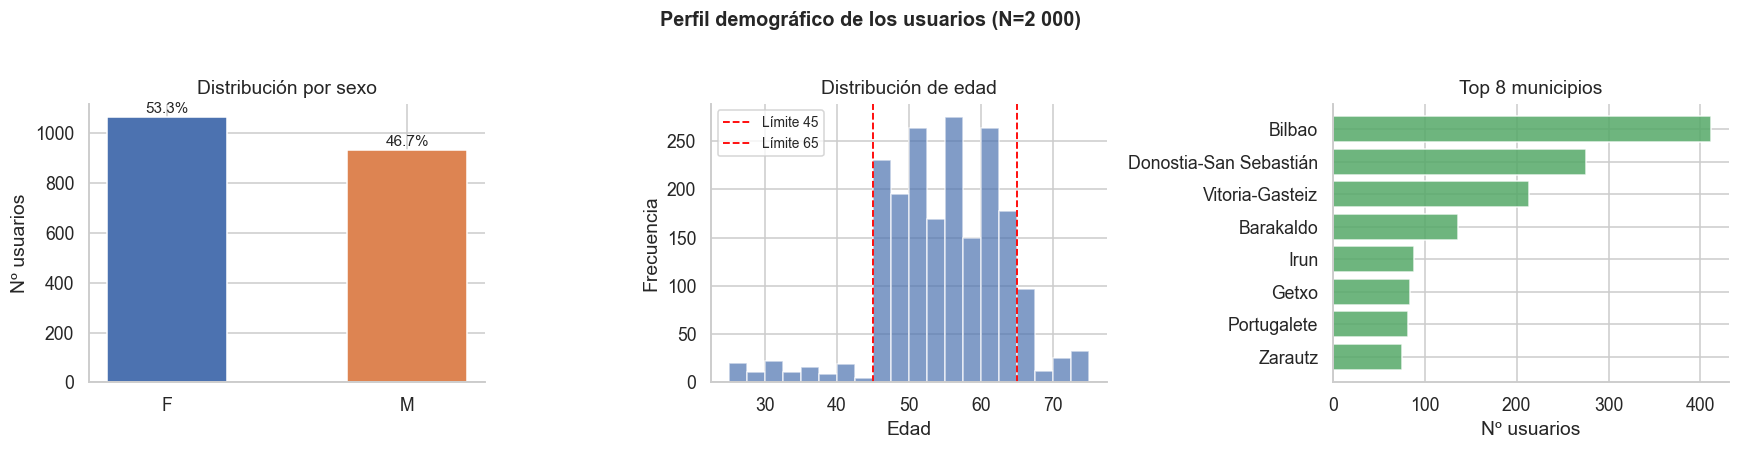

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── 3.1 Sexo
sexo_counts = eventos["Sexo"].value_counts()
axes[0].bar(sexo_counts.index, sexo_counts.values, color=[COL_EVT, COL_GAST], width=0.5)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 f"{bar.get_height()/len(eventos)*100:.1f}%", ha="center", fontsize=10)
axes[0].set_title("Distribución por sexo")
axes[0].set_ylabel("Nº usuarios")

# ── 3.2 Edad (histograma + KDE)
axes[1].hist(eventos["Edad"], bins=20, color=COL_EVT, alpha=0.7, edgecolor="white")
axes[1].axvline(45, color="red", ls="--", lw=1.2, label="Límite 45")
axes[1].axvline(65, color="red", ls="--", lw=1.2, label="Límite 65")
axes[1].set_title("Distribución de edad")
axes[1].set_xlabel("Edad")
axes[1].set_ylabel("Frecuencia")
axes[1].legend(fontsize=9)

# ── 3.3 Municipios (top 8)
top_munis = eventos["Municipio"].value_counts().head(8)
axes[2].barh(top_munis.index[::-1], top_munis.values[::-1], color=COL_LUG, alpha=0.85)
axes[2].set_title("Top 8 municipios")
axes[2].set_xlabel("Nº usuarios")

plt.suptitle("Perfil demográfico de los usuarios (N=2 000)", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [13]:
# Verificar distribución territorial real vs objetivo
def territorio(mun):
    biz = ["Bilbao","Getxo","Barakaldo","Basauri","Leioa","Portugalete",
           "Santurtzi","Durango","Bermeo","Mungia"]
    gip = ["Donostia-San Sebastián","Irun","Errenteria","Zarautz","Eibar",
           "Tolosa","Hernani","Azpeitia","Beasain"]
    return "Bizkaia" if mun in biz else ("Gipuzkoa" if mun in gip else "Araba")

for nombre, df in [("Eventos", eventos), ("Gastronomía", gastro), ("Lugares", lugares)]:
    t = df["Municipio"].map(territorio).value_counts(normalize=True)*100
    print(f"{nombre:15s} → Bizkaia {t.get('Bizkaia',0):.1f}%  "
          f"Gipuzkoa {t.get('Gipuzkoa',0):.1f}%  "
          f"Araba {t.get('Araba',0):.1f}%  "
          f"(objetivo: 50 / 35 / 15)")


Eventos         → Bizkaia 50.9%  Gipuzkoa 35.0%  Araba 14.1%  (objetivo: 50 / 35 / 15)
Gastronomía     → Bizkaia 50.1%  Gipuzkoa 35.5%  Araba 14.4%  (objetivo: 50 / 35 / 15)
Lugares         → Bizkaia 48.3%  Gipuzkoa 36.5%  Araba 15.2%  (objetivo: 50 / 35 / 15)


---
## 4 · Distribución del Target (puntuaciones 1-5)

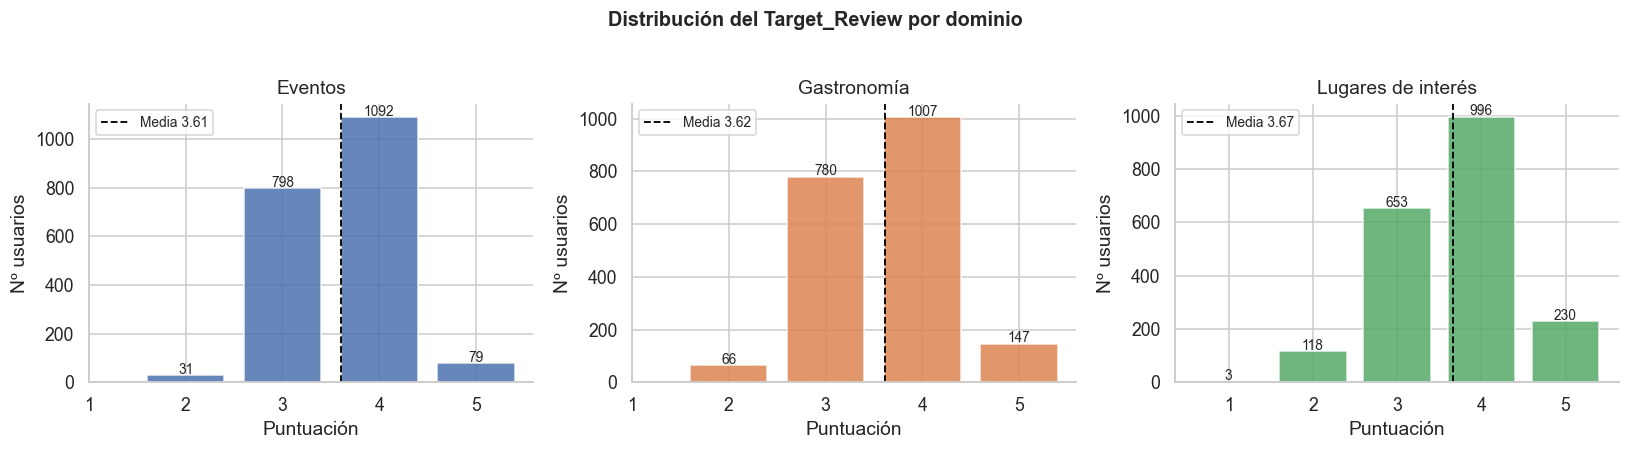

Eventos                 media=3.61  mediana=4  std=0.59  skew=-0.08
Gastronomía             media=3.62  mediana=4  std=0.67  skew=-0.03
Lugares de interés      media=3.67  mediana=4  std=0.76  skew=-0.24


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
colores = [COL_EVT, COL_GAST, COL_LUG]
titulos = ["Eventos", "Gastronomía", "Lugares de interés"]
dfs     = [eventos, gastro, lugares]

for ax, df, color, titulo in zip(axes, dfs, colores, titulos):
    counts = df["Target_Review"].value_counts().sort_index()
    bars = ax.bar(counts.index, counts.values, color=color, alpha=0.85, edgecolor="white")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f"{bar.get_height()}", ha="center", fontsize=9)
    ax.set_title(titulo)
    ax.set_xlabel("Puntuación")
    ax.set_ylabel("Nº usuarios")
    ax.set_xticks([1,2,3,4,5])
    media = df["Target_Review"].mean()
    ax.axvline(media, color="black", ls="--", lw=1.2, label=f"Media {media:.2f}")
    ax.legend(fontsize=9)

plt.suptitle("Distribución del Target_Review por dominio", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Estadísticos
for nombre, df in zip(titulos, dfs):
    r = df["Target_Review"]
    print(f"{nombre:22s}  media={r.mean():.2f}  mediana={r.median():.0f}  "
          f"std={r.std():.2f}  skew={r.skew():.2f}")


---
## 5 · Tasa de interés por categoría

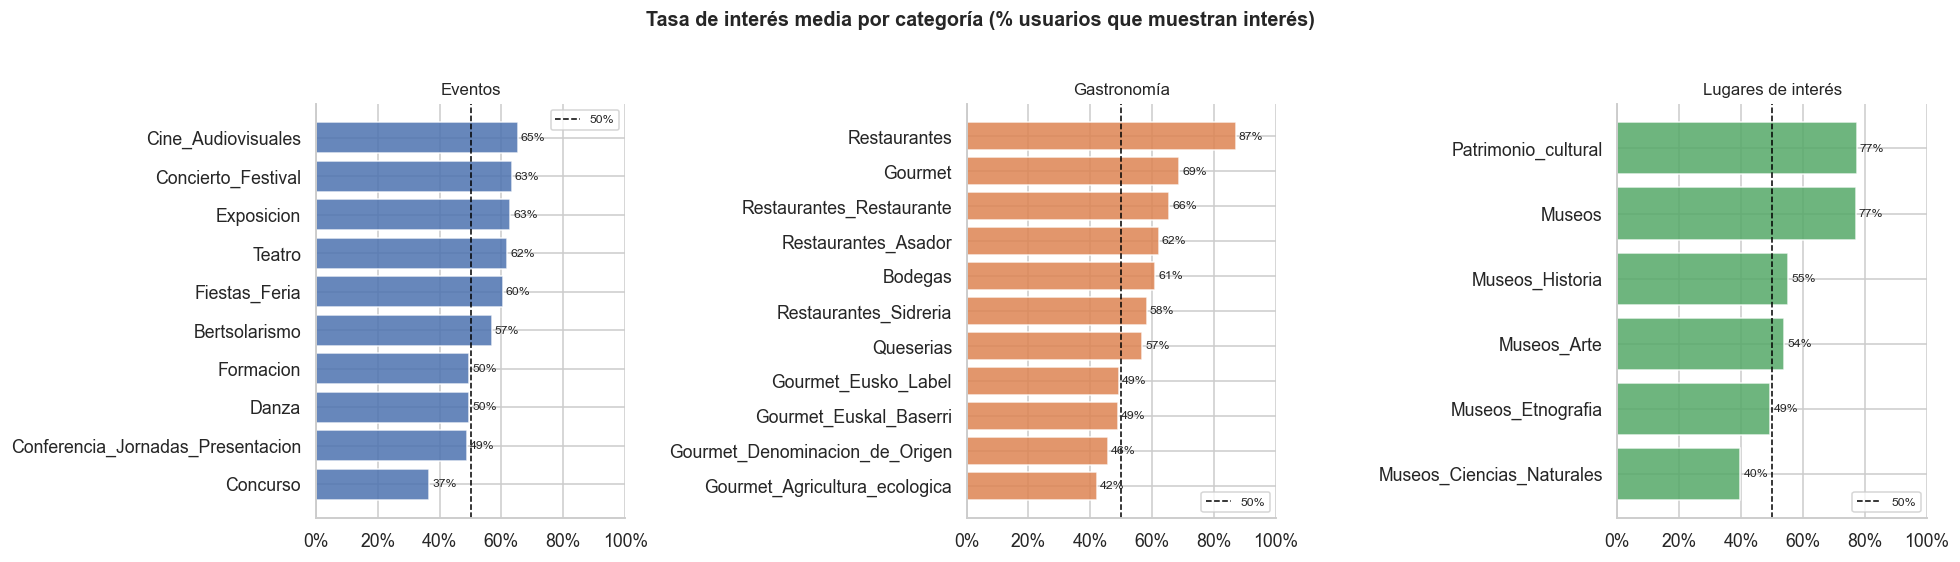

In [15]:
def cols_preferencia(df):
    excluir = {"Id_user","Sexo","Edad","Municipio","Target_Review"}
    return [c for c in df.columns if c not in excluir]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, df, color, titulo in zip(axes, dfs, colores, titulos):
    cols = cols_preferencia(df)
    means = df[cols].mean().sort_values(ascending=True)
    ax.barh(means.index, means.values, color=color, alpha=0.85)
    ax.axvline(0.5, color="black", ls="--", lw=1, label="50%")
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(titulo, fontsize=11)
    ax.legend(fontsize=8)
    for i, (v, label) in enumerate(zip(means.values, means.index)):
        ax.text(v + 0.01, i, f"{v*100:.0f}%", va="center", fontsize=8)

plt.suptitle("Tasa de interés media por categoría (% usuarios que muestran interés)",
             y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## 6 · Correlación entre categorías

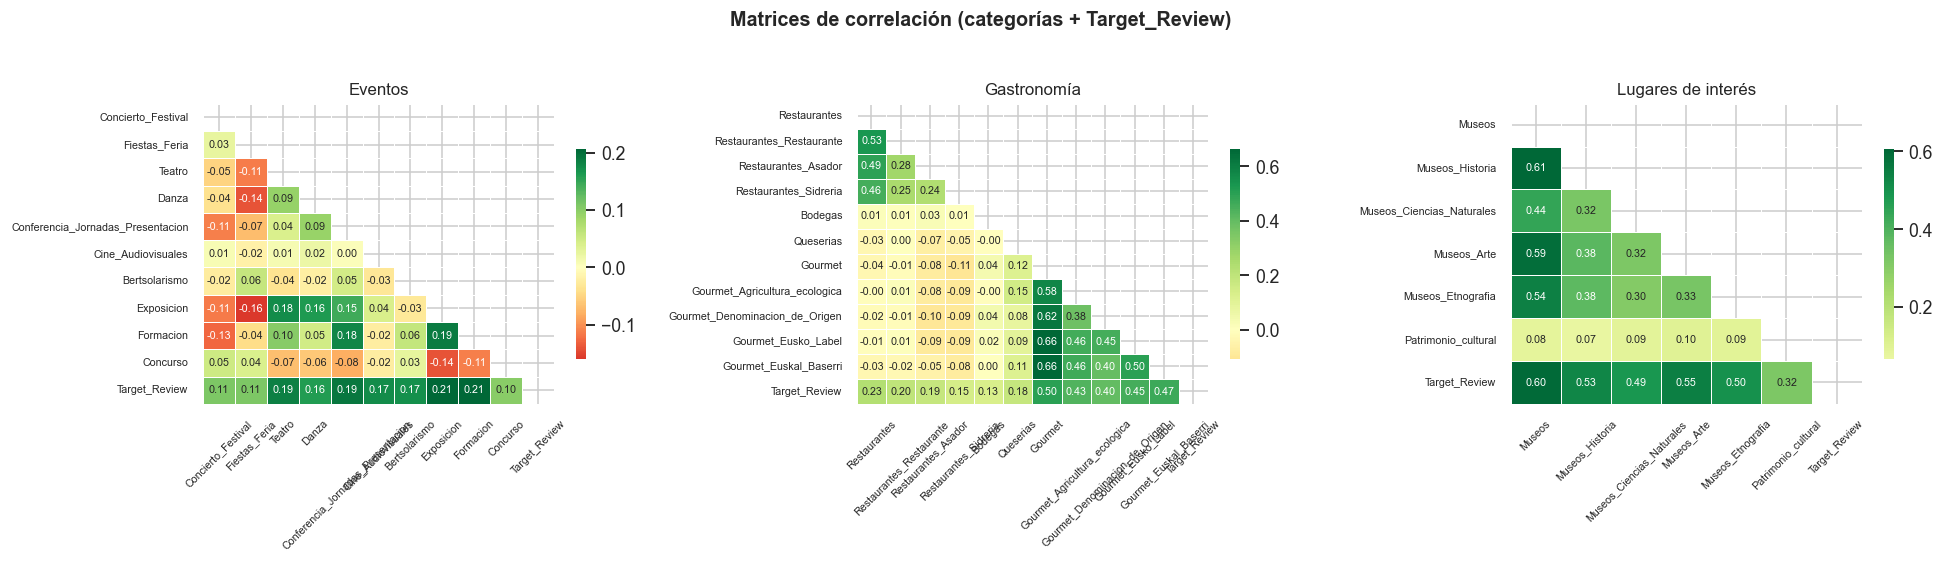

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, df, titulo in zip(axes, dfs, titulos):
    cols = cols_preferencia(df)
    corr = df[cols + ["Target_Review"]].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, ax=ax, annot=True, fmt=".2f",
                cmap="RdYlGn", center=0, linewidths=0.4,
                annot_kws={"size": 7}, cbar_kws={"shrink": 0.7})
    ax.set_title(titulo, fontsize=11)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

plt.suptitle("Matrices de correlación (categorías + Target_Review)",
             y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
# No nos importan las correlaciones porque vamos a entrenar el modelo LightGBM, al que no le afectan las relaciones lineales.

---
## 7 · Nº de intereses por usuario y relación con el Target

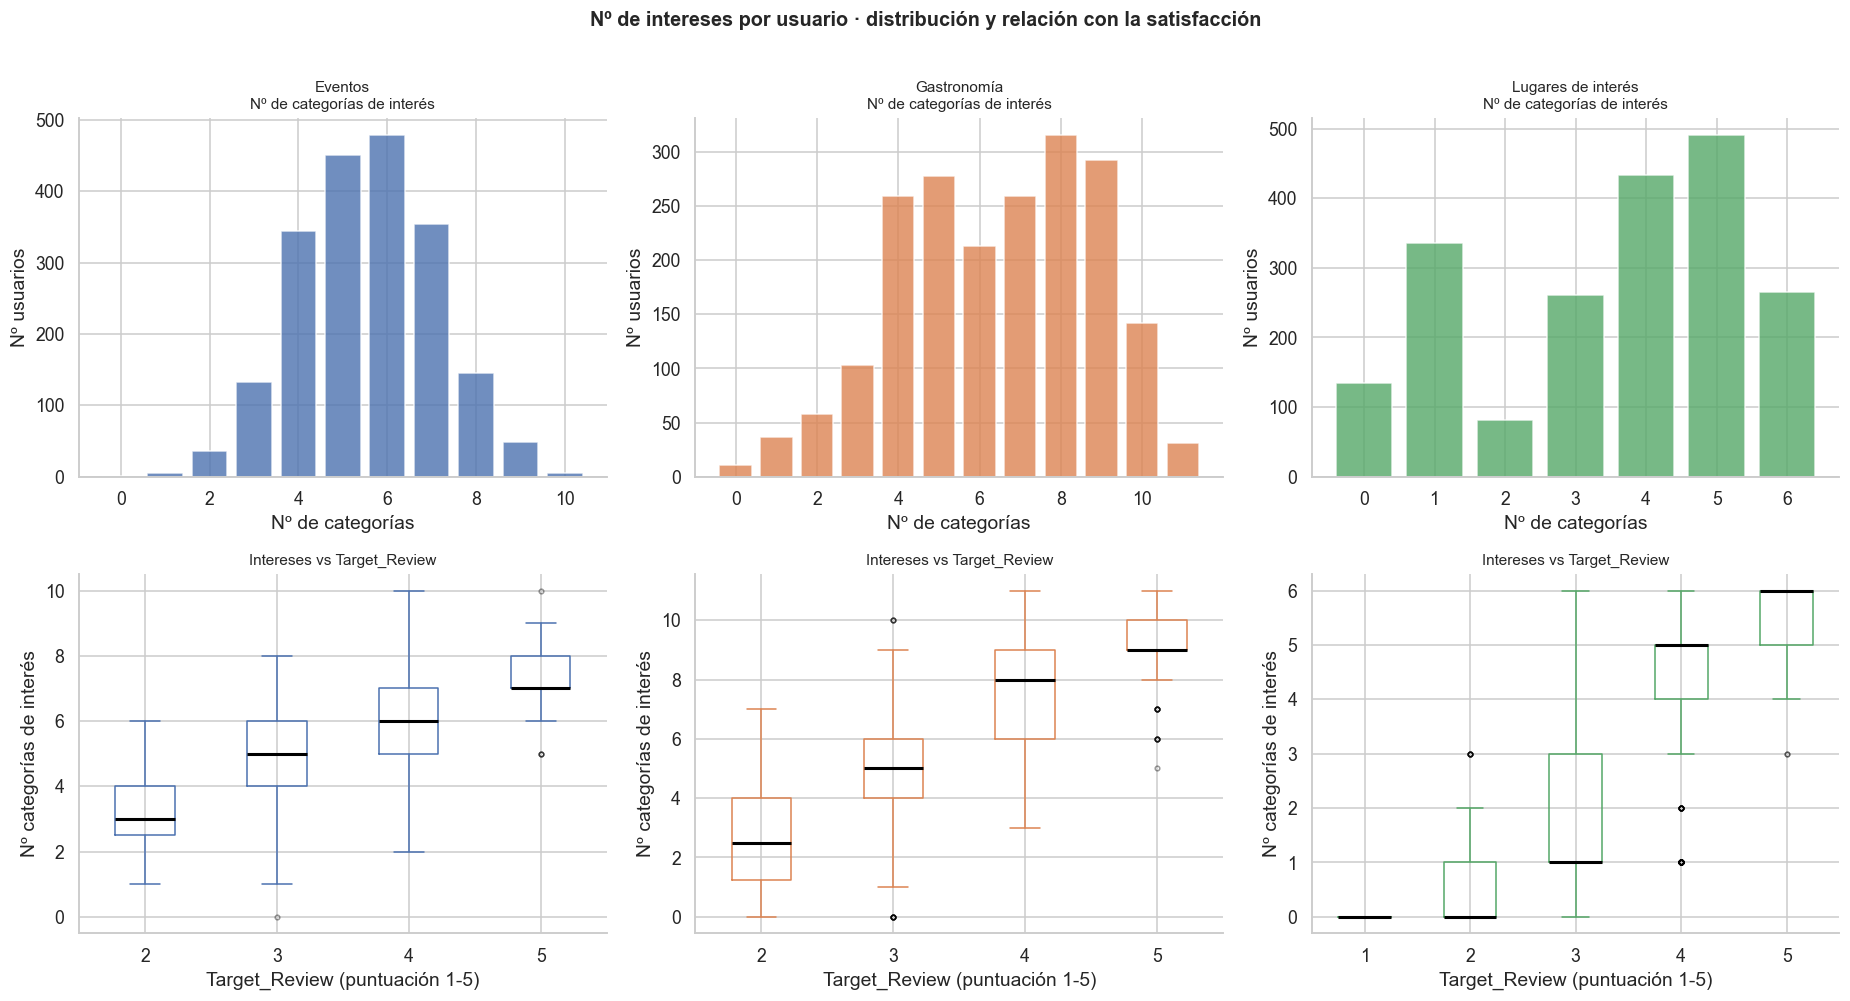

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

for col_idx, (df, color, titulo) in enumerate(zip(dfs, colores, titulos)):
    cols = cols_preferencia(df)
    df = df.copy()
    df["n_intereses"] = df[cols].sum(axis=1)

    # Fila 0 — distribución del nº de intereses
    ax0 = axes[0, col_idx]
    counts = df["n_intereses"].value_counts().sort_index()
    ax0.bar(counts.index, counts.values, color=color, alpha=0.8, edgecolor="white")
    ax0.set_title(f"{titulo}\nNº de categorías de interés", fontsize=10)
    ax0.set_xlabel("Nº de categorías")
    ax0.set_ylabel("Nº usuarios")

    # Fila 1 — boxplot por Target
    ax1 = axes[1, col_idx]
    df.boxplot(column="n_intereses", by="Target_Review", ax=ax1,
               boxprops=dict(color=color), medianprops=dict(color="black", lw=2),
               whiskerprops=dict(color=color), capprops=dict(color=color),
               flierprops=dict(marker=".", alpha=0.4, color=color))
    ax1.set_title(f"Intereses vs Target_Review", fontsize=10)
    ax1.set_xlabel("Target_Review (puntuación 1-5)")
    ax1.set_ylabel("Nº categorías de interés")

plt.suptitle("Nº de intereses por usuario · distribución y relación con la satisfacción",
             y=1.01, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


Fila superior — Distribución del nº de categorías de interés:  
Muestra cuántas categorías le interesan a cada usuario dentro de su dominio.
* Eventos (azul, 10 categorías posibles): distribución aproximadamente normal centrada en 5-6 categorías. La mayoría de usuarios tiene un perfil amplio, lo que tiene sentido porque los buyer personas son culturalmente activos.
* Gastronomía (naranja, 11 categorías posibles): distribución desplazada hacia la derecha, con el grueso entre 7-9 categorías. Los usuarios tienden a tener interés en muchas subcategorías gastronómicas a la vez, algo coherente con que Restaurantes y Gourmet (categorías padre de alta probabilidad) arrastran consigo a sus hijos.
* Lugares de interés (verde, solo 6 categorías posibles): distribución bimodal con picos en 1 y en 4-5. Refleja que hay un grupo de usuarios poco interesados en museos y otro muy interesado en casi todo el catálogo. Al tener pocas categorías, la variabilidad es más visible.

Fila inferior — Boxplots: nº de intereses según la puntuación dada (Target_Review):  
Aquí está la información más relevante para el modelo. En los tres dominios se aprecia la misma tendencia clara: a mayor número de categorías de interés, mayor puntuación media. Esto valida que el target sintético está bien construido, ya que la satisfacción aumenta de forma monótona con la afinidad temática del usuario.  
Algunos matices:  
* En Eventos y Gastronomía la separación entre grupos de Target es muy limpia y progresiva, con cajas que apenas se solapan entre puntuaciones contiguas. Buena señal para LightGBM.
* En Lugares de interés la separación también existe pero las cajas son más anchas y con más solapamiento, especialmente entre Target 3 y 4. Esto se debe al rango limitado de categorías (0-6), que comprime la varianza y hace más difícil discriminar niveles intermedios.
Los outliers (puntos individuales) son escasos y razonables: algún usuario con pocas categorías de interés que aun así dio puntuación alta, o viceversa.

---
## 8 · Segmentación por sexo y edad

C:\Users\cchia\AppData\Local\Temp\ipykernel_26096\1929245046.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = df.groupby(["grupo_edad","Sexo"])["n_intereses"].mean().unstack()
C:\Users\cchia\AppData\Local\Temp\ipykernel_26096\1929245046.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  target_edad = df.groupby("grupo_edad")["Target_Review"].mean()
C:\Users\cchia\AppData\Local\Temp\ipykernel_26096\1929245046.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True t

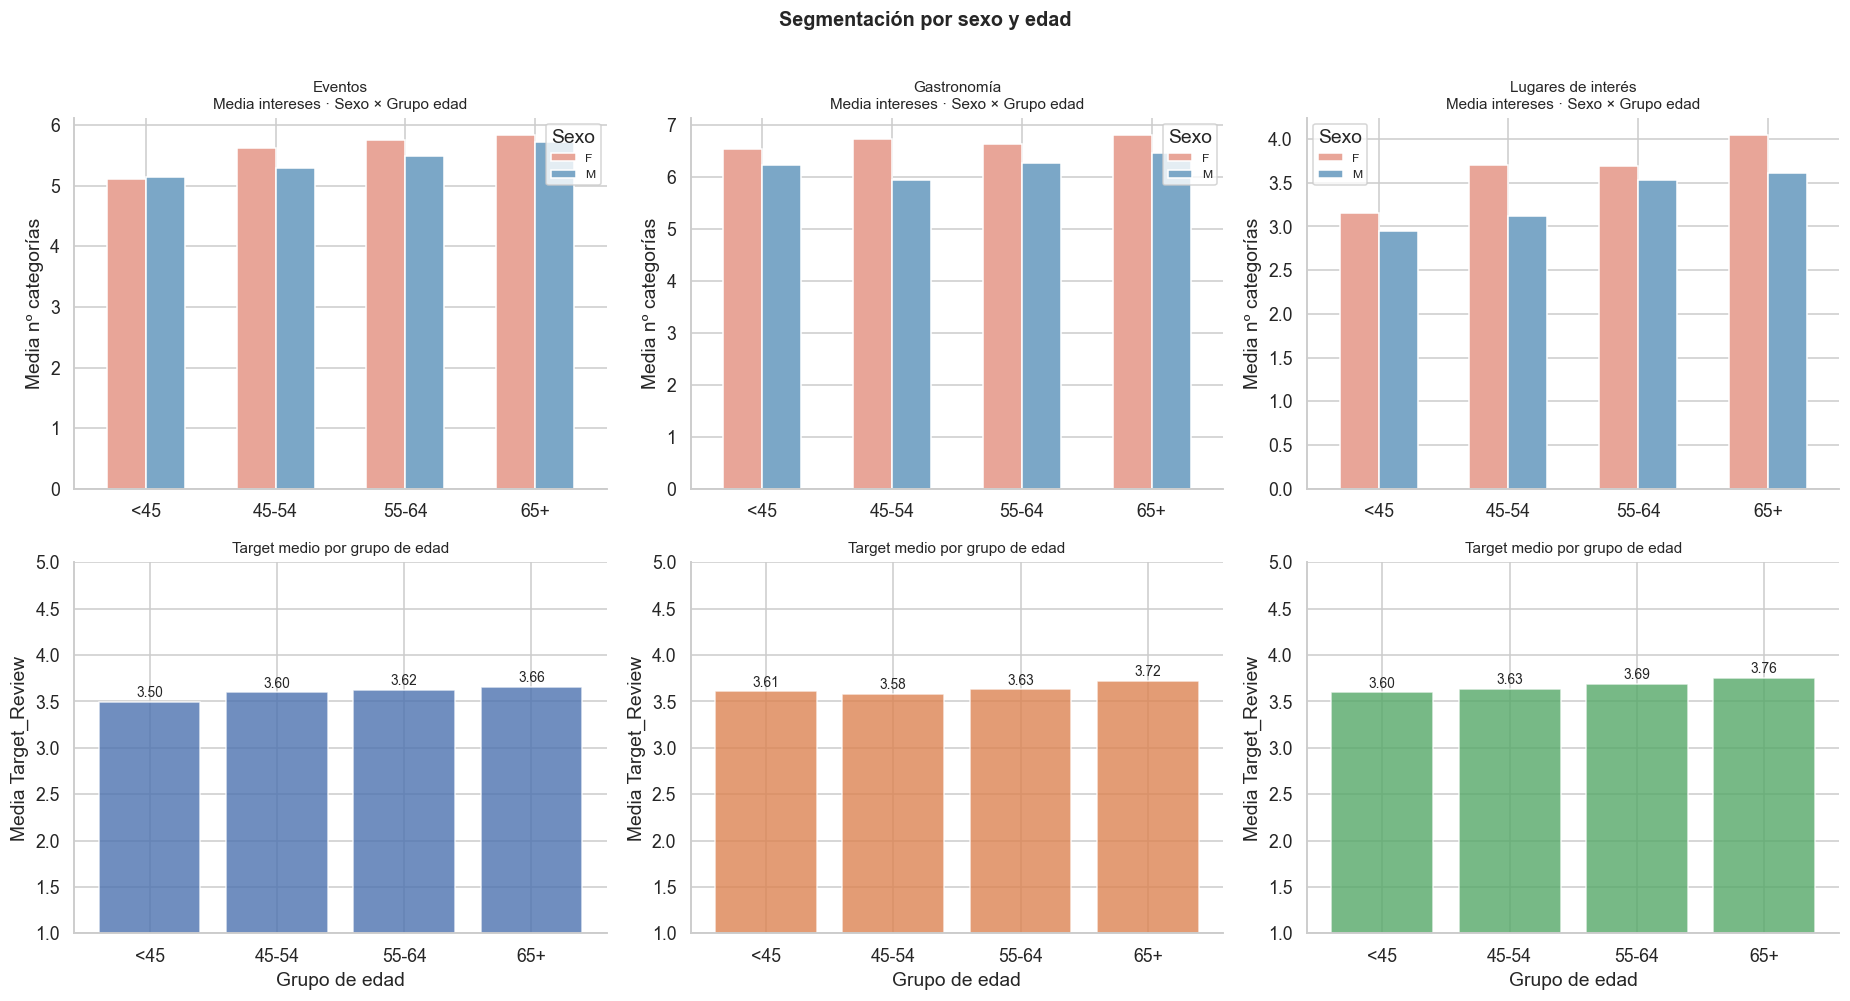

In [18]:
bins   = [0, 44, 54, 64, 100]
labels = ["<45", "45-54", "55-64", "65+"]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

for col_idx, (df, color, titulo) in enumerate(zip(dfs, colores, titulos)):
    df = df.copy()
    cols = cols_preferencia(df)
    df["grupo_edad"] = pd.cut(df["Edad"], bins=bins, labels=labels)
    df["n_intereses"] = df[cols].sum(axis=1)

    # Fila 0 — media de intereses por sexo y grupo de edad
    ax0 = axes[0, col_idx]
    pivot = df.groupby(["grupo_edad","Sexo"])["n_intereses"].mean().unstack()
    pivot.plot(kind="bar", ax=ax0, rot=0, width=0.6,
               color=["#E8A598","#7BA7C7"], edgecolor="white")
    ax0.set_title(f"{titulo}\nMedia intereses · Sexo × Grupo edad", fontsize=10)
    ax0.set_xlabel("")
    ax0.set_ylabel("Media nº categorías")
    ax0.legend(title="Sexo", fontsize=8)

    # Fila 1 — Target medio por grupo de edad
    ax1 = axes[1, col_idx]
    target_edad = df.groupby("grupo_edad")["Target_Review"].mean()
    ax1.bar(target_edad.index, target_edad.values, color=color, alpha=0.8, edgecolor="white")
    ax1.set_ylim(1, 5)
    ax1.set_title(f"Target medio por grupo de edad", fontsize=10)
    ax1.set_xlabel("Grupo de edad")
    ax1.set_ylabel("Media Target_Review")
    for i, v in enumerate(target_edad.values):
        ax1.text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=9)

plt.suptitle("Segmentación por sexo y edad",
             y=1.01, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## 9 · Análisis territorial

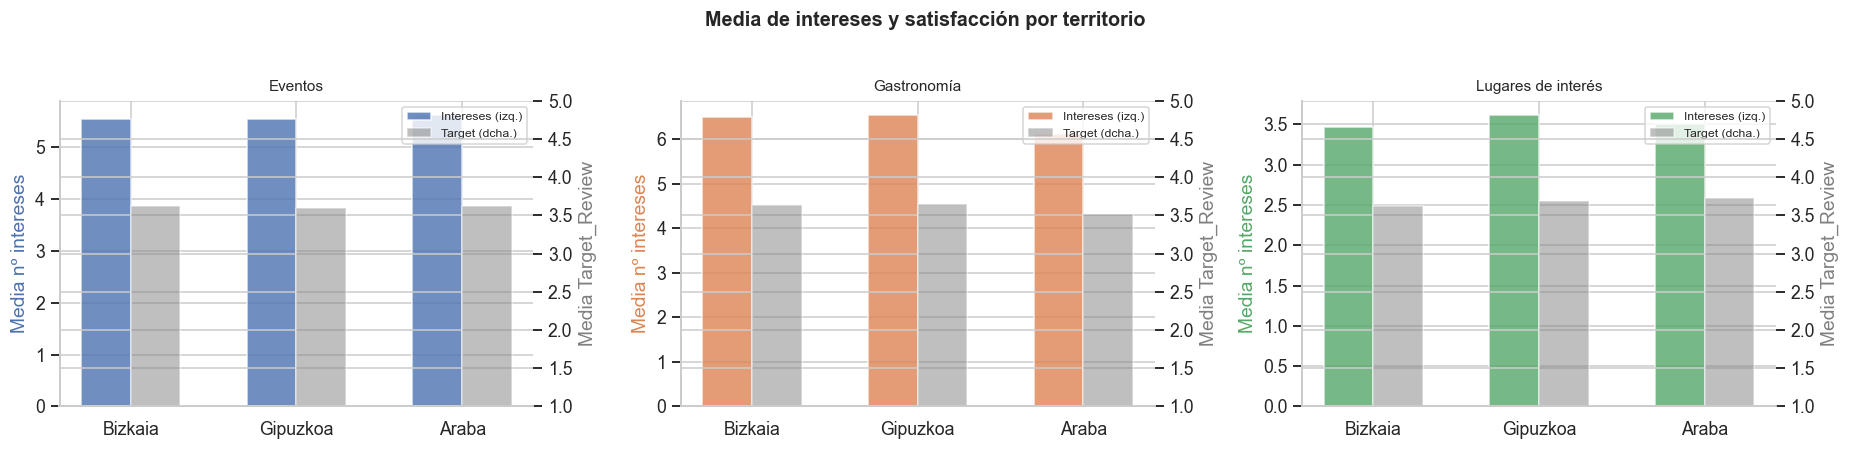

In [19]:
def add_territorio(df):
    biz = ["Bilbao","Getxo","Barakaldo","Basauri","Leioa","Portugalete",
           "Santurtzi","Durango","Bermeo","Mungia"]
    gip = ["Donostia-San Sebastián","Irun","Errenteria","Zarautz","Eibar",
           "Tolosa","Hernani","Azpeitia","Beasain"]
    df = df.copy()
    df["Territorio"] = df["Municipio"].apply(
        lambda m: "Bizkaia" if m in biz else ("Gipuzkoa" if m in gip else "Araba"))
    return df

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, df, color, titulo in zip(axes, dfs, colores, titulos):
    df2 = add_territorio(df)
    cols = cols_preferencia(df)
    df2["n_intereses"] = df2[cols].sum(axis=1)
    agg = df2.groupby("Territorio").agg(
        n_usuarios=("Id_user","count"),
        media_intereses=("n_intereses","mean"),
        media_target=("Target_Review","mean")
    ).reindex(["Bizkaia","Gipuzkoa","Araba"])

    x = np.arange(3)
    w = 0.3
    ax2 = ax.twinx()
    ax.bar(x - w/2, agg["media_intereses"], w, color=color, alpha=0.8, label="Intereses (izq.)")
    ax2.bar(x + w/2, agg["media_target"], w, color="gray", alpha=0.5, label="Target (dcha.)")
    ax.set_xticks(x)
    ax.set_xticklabels(agg.index)
    ax.set_title(titulo, fontsize=10)
    ax.set_ylabel("Media nº intereses", color=color)
    ax2.set_ylabel("Media Target_Review", color="gray")
    ax2.set_ylim(1, 5)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle("Media de intereses y satisfacción por territorio",
             y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## 10 · Coherencia padre-hijo (validación de calidad de datos)

In [20]:
print("Verificación de coherencia padre → hijos\n")

checks = {
    "Gastronomía": {
        "df": gastro,
        "reglas": [
            ("Restaurantes", ["Restaurantes_Restaurante","Restaurantes_Asador","Restaurantes_Sidreria"]),
            ("Gourmet",      ["Gourmet_Agricultura_ecologica","Gourmet_Denominacion_de_Origen",
                               "Gourmet_Eusko_Label","Gourmet_Euskal_Baserri"]),
        ]
    },
    "Lugares de interés": {
        "df": lugares,
        "reglas": [
            ("Museos", ["Museos_Historia","Museos_Ciencias_Naturales","Museos_Arte","Museos_Etnografia"]),
        ]
    },
}

for dominio, info in checks.items():
    df_ = info["df"]
    print(f"  {dominio}:")
    for padre, hijas in info["reglas"]:
        viol = ((df_[padre] == 0) & (df_[hijas].max(axis=1) == 1)).sum()
        status = "✅ OK" if viol == 0 else f"⚠️  {viol} violaciones"
        print(f"    {padre:35s} → hijo=1 cuando padre=0: {status}")
    print()


Verificación de coherencia padre → hijos

  Gastronomía:
    Restaurantes                        → hijo=1 cuando padre=0: ✅ OK
    Gourmet                             → hijo=1 cuando padre=0: ✅ OK

  Lugares de interés:
    Museos                              → hijo=1 cuando padre=0: ✅ OK



---
## 11 · Resumen ejecutivo

| Aspecto | Eventos | Gastronomía | Lugares de interés |
|---------|---------|-------------|-------------------|
| Registros | 2 000 | 2 000 | 2 000 |
| Categorías de preferencia | 10 | 11 | 6 |
| Distribución territorial | ≈50/35/15 | ≈50/35/15 | ≈50/35/15 |
| Edad predominante | 45-65 (≈90%) | 45-65 (≈90%) | 45-65 (≈90%) |
| Categoría más demandada | Cine_Audiovisuales | Restaurantes | Patrimonio_cultural |
| Target medio | ~3.5 | ~3.7 | ~3.9 |
| Coherencia padre-hijo | — | ✅ | ✅ |

**Observaciones clave:**
- La distribución territorial se ajusta bien a los objetivos (50/35/15).
- El sesgo hacia puntuaciones 3-4 en el target es esperable con datos sintéticos; en producción convendría balancear clases para el modelo.
- Las correlaciones inter-categorías son moderadas (0.2-0.5), lo que indica variabilidad suficiente para entrenar LightGBM.
- Las subcategorías de Gourmet y Museos tienen correlación alta con sus padres, como es lógico por la coherencia impuesta.
